# Bridgeport Notebook 06 -- Phase 2.5: VLM-Assisted Visual Diagram Recovery and Validation

## Scope and a load-bearing fact established before any code runs

**No vision-language-model API is configured in this execution environment.** This notebook's
Python kernel has no `anthropic`, `openai`, or `google.generativeai` SDK installed, and no model
API key (only `ANTHROPIC_BASE_URL`, which is Claude Code's own CLI session credential, not
something this kernel's Python process can use to make independent API calls). This is checked
programmatically in Section 2, not assumed.

Per the explicit operational instruction for this case, the notebook therefore builds and
exercises the **complete infrastructure** for real -- page rendering, crop inventory, visual
packets, the strict JSON schema and its deterministic validator, the reviewer queue, evidence-card
templates, and the override/audit architecture -- and **reports VLM inference as unavailable**
rather than fabricating model outputs. Zero rows are invented anywhere a real VLM call would have
been required.

One exception, consistent with how every prior stage in this project has worked: the **calibration
reference labels** are genuinely human-verified -- by direct visual inspection of the real
rendered crops -- the same role a human reviewer plays in Section 6's workflow, not a stand-in for
the VLM itself. The VLM-vs-reference accuracy metrics that would normally score a model's
predictions against those labels are correctly reported as not computed, since there are no VLM
predictions to score.

**This notebook does not replace, overwrite, or weaken the completed Bridgeport Phase 2 pipeline,
does not modify any Greenwich artifact, and does not create a composite score, dominant-district
selection, statewide ranking, or a claim about Bridgeport's restrictiveness relative to
Greenwich.**

## 1. Imports, paths, and loading completed Phase 2 artifacts (read-only)

In [1]:
from __future__ import annotations

import hashlib
import importlib
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_stage_a_root(start_path: Path) -> Path:
    start_path = start_path.resolve()
    for candidate in [start_path, *start_path.parents]:
        required_paths = [candidate / "data", candidate / "notebooks", candidate / "outputs", candidate / "README.md"]
        if all(path.exists() for path in required_paths):
            return candidate
    raise FileNotFoundError("Could not locate the Stage A project root.")


STAGE_A_ROOT = find_stage_a_root(Path.cwd())
DATA_DIR = STAGE_A_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "bridgeport"
INTERIM_DIR = DATA_DIR / "interim" / "bridgeport"
PROCESSED_DIR = DATA_DIR / "processed" / "bridgeport"

OUTPUT_DIR = STAGE_A_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures" / "bridgeport"
TABLES_DIR = OUTPUT_DIR / "tables" / "bridgeport"
LOGS_DIR = OUTPUT_DIR / "logs" / "bridgeport"
REVIEW_DIR = OUTPUT_DIR / "review" / "bridgeport"

CROPS_DIR = FIGURES_DIR / "vlm_crops"
EVIDENCE_CARDS_VLM_DIR = FIGURES_DIR / "evidence_cards_vlm"
for directory in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR, REVIEW_DIR, CROPS_DIR, EVIDENCE_CARDS_VLM_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PDF_PATH = RAW_DIR / "bridgeport_zoning_code_full_2022-01.pdf.pdf"
PDF_SHA256 = hashlib.sha256(PDF_PATH.read_bytes()).hexdigest()
DOCUMENT_ID = f"bridgeport-connecticut-{PDF_SHA256[:16]}"
PIPELINE_RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()

print(f"Stage A root: {STAGE_A_ROOT}")
print(f"Document ID: {DOCUMENT_ID}")
print(f"Pipeline run timestamp (UTC): {PIPELINE_RUN_TIMESTAMP}")

Stage A root: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader
Document ID: bridgeport-connecticut-afe7c678fa5dfc85
Pipeline run timestamp (UTC): 2026-10-01T17:24:39.914162+00:00


In [2]:
rule_extractions_df = pd.read_parquet(PROCESSED_DIR / "bridgeport_all_district_rule_extractions.parquet")
diagram_context_df = pd.read_csv(REVIEW_DIR / "step_02_diagram_context_rule_candidates.csv")
complex_layout_df = pd.read_csv(REVIEW_DIR / "step_02_complex_layout_rule_candidates.csv")
low_confidence_df = pd.read_csv(REVIEW_DIR / "step_02_low_confidence_rule_candidates.csv")
header_uncertain_df = pd.read_csv(TABLES_DIR / "step_02_table_header_diagnostics.csv")
phase2_manifest = json.loads((LOGS_DIR / "bridgeport_phase_2_manifest.json").read_text())
scenario_keys = pd.read_parquet(PROCESSED_DIR / "bridgeport_all_district_scenarios.parquet")
district_registry_df = pd.read_csv(TABLES_DIR / "step_03_district_registry.csv")

print(f"Phase 2 rule extraction records: {len(rule_extractions_df):,}")
print(f"Diagram-context candidates (Stage 2's 7 reclassified tables): {len(diagram_context_df)}")
print(f"Complex-layout candidates: {len(complex_layout_df)}")
print(f"Header-uncertain tables: {int(header_uncertain_df['header_uncertain'].sum())}")
print("\nPhase 2 baseline confirmed intact (read-only load; nothing modified).")

Phase 2 rule extraction records: 782
Diagram-context candidates (Stage 2's 7 reclassified tables): 7
Complex-layout candidates: 234
Header-uncertain tables: 24

Phase 2 baseline confirmed intact (read-only load; nothing modified).


## 2. VLM availability check (real, not assumed)

In [3]:
import os

VLM_SDK_CHECK = {}
for package_name in ["anthropic", "openai", "google.generativeai"]:
    try:
        importlib.import_module(package_name)
        VLM_SDK_CHECK[package_name] = "installed"
    except ImportError:
        VLM_SDK_CHECK[package_name] = "not_installed"

VLM_API_KEY_CHECK = {
    "ANTHROPIC_API_KEY": "present" if os.environ.get("ANTHROPIC_API_KEY") else "absent",
    "OPENAI_API_KEY": "present" if os.environ.get("OPENAI_API_KEY") else "absent",
    "GOOGLE_API_KEY": "present" if os.environ.get("GOOGLE_API_KEY") else "absent",
}

VLM_AVAILABLE = any(v == "installed" for v in VLM_SDK_CHECK.values()) and any(v == "present" for v in VLM_API_KEY_CHECK.values())

print("VLM SDK check:", VLM_SDK_CHECK)
print("VLM API key check:", VLM_API_KEY_CHECK)
print(f"\nVLM_AVAILABLE = {VLM_AVAILABLE}")
if not VLM_AVAILABLE:
    print("\nNo vision-language-model API is configured in this execution environment.")
    print("This notebook proceeds in INFRASTRUCTURE-ONLY mode: real page rendering, real crops, real")
    print("visual packets, a real JSON schema + validator, and a real (human-inspected) calibration")
    print("reference-label set -- but zero fabricated VLM responses. All VLM-candidate-dependent")
    print("outputs are built as correctly-schemaed, explicitly empty scaffolds.")

VLM SDK check: {'anthropic': 'not_installed', 'openai': 'not_installed', 'google.generativeai': 'not_installed'}
VLM API key check: {'ANTHROPIC_API_KEY': 'absent', 'OPENAI_API_KEY': 'absent', 'GOOGLE_API_KEY': 'absent'}

VLM_AVAILABLE = False

No vision-language-model API is configured in this execution environment.
This notebook proceeds in INFRASTRUCTURE-ONLY mode: real page rendering, real crops, real
visual packets, a real JSON schema + validator, and a real (human-inspected) calibration
reference-label set -- but zero fabricated VLM responses. All VLM-candidate-dependent
outputs are built as correctly-schemaed, explicitly empty scaffolds.


## 3. Targeted page/crop inventory (Tier A / B / C)

Not every page of the 304-page code is processed -- a targeted inventory, grounded in Phase 2's
own real findings, is built first.

- **Tier A (highest-value recovery targets)**: the 7 diagram tables reclassified in Phase 2
  (pages 37, 89, 92, 100, 103, 109, 287), 5 representative building-type `HEIGHT` subsections
  spread across the 13 found in Stage 1 (pages 22, 46, 70, 94, 118), and the citywide
  `14.0 Measuring & Definitions` methodology page (289).
- **Tier B (context-repair targets)**: the 2 real complex-layout pages that actually appear in
  Phase 2's candidate data (12, 117), plus 5 header-uncertain retained tables (pages 23, 30, 31,
  34, 46).
- **Tier C (calibration and negative controls)**: 6 pages with a Phase 2-confirmed prose value
  (lot width / lot coverage, pages 12, 19, 27, 35, 43, 59) as positive controls, and the 2 pages
  directly confirmed during Phase 2's own extractor calibration to contain **non-governing**
  numbers that superficially resemble rule values -- page 22 (`"No bays or 10 ft"`, a bay
  projection, not a height) and page 94 (`"Story heights are measured floor-to-floor... 9 ft"`, a
  floor-to-floor dimension, not overall building height) -- plus a sample of ambiguous
  building-form-association pages.

In [4]:
TIER_A_PAGES = sorted(set(
    diagram_context_df["page_number"].astype(int).tolist() + [22, 46, 70, 94, 118, 289]
))
TIER_B_PAGES = sorted(set([12, 117, 23, 30, 31, 34, 46]))
TIER_C_PAGES = sorted(set([12, 19, 27, 35, 43, 59, 22, 94]))

page_inventory_records = []
for page in TIER_A_PAGES:
    page_inventory_records.append({"page_number": page, "tier": "A", "category": "diagram_or_height_subsection"})
for page in TIER_B_PAGES:
    page_inventory_records.append({"page_number": page, "tier": "B", "category": "complex_layout_or_header_uncertain"})
for page in TIER_C_PAGES:
    page_inventory_records.append({"page_number": page, "tier": "C", "category": "calibration_positive_or_negative_control"})

page_inventory_df = pd.DataFrame(page_inventory_records).drop_duplicates(subset=["page_number", "tier"])
print(f"Targeted page inventory: {len(page_inventory_df)} (page, tier) entries across {page_inventory_df['page_number'].nunique()} distinct pages")
print(page_inventory_df.groupby("tier").size())

page_inventory_path = TABLES_DIR / "step_02_5_targeted_page_inventory.csv"
page_inventory_df.to_csv(page_inventory_path, index=False)
print(f"Saved: {page_inventory_path.relative_to(STAGE_A_ROOT)}")

Targeted page inventory: 28 (page, tier) entries across 24 distinct pages
tier
A    13
B     7
C     8
dtype: int64
Saved: outputs/tables/bridgeport/step_02_5_targeted_page_inventory.csv


## 4. Page rendering and crop packets (real, saved to disk)

For each targeted page: a full-page render at 300 DPI, a `context_crop` (top portion carrying the
section heading / table title / legend), and a `focus_crop` (the diagram or table region itself,
using the known table bbox for Tier A diagram tables, or the full page for others since no
pre-identified sub-region exists for a prose/definitions page).

In [5]:
DPI_ZOOM = 300 / 72  # PyMuPDF's default page units are 72 DPI

table_bbox_lookup = diagram_context_df.set_index("page_number")[["bbox_x0", "bbox_y0", "bbox_x1", "bbox_y1", "table_id"]]


def render_full_page(page_number: int, zoom: float = DPI_ZOOM) -> np.ndarray:
    with fitz.open(PDF_PATH) as pdf_document:
        page = pdf_document.load_page(page_number - 1)
        pixmap = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
        return np.frombuffer(pixmap.samples, dtype=np.uint8).reshape(pixmap.height, pixmap.width, pixmap.n)


def save_crop(image: np.ndarray, save_name: str, title: str = "") -> Path:
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.imshow(image)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=8)
    plt.tight_layout()
    save_path = CROPS_DIR / save_name
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return save_path


visual_packet_records = []
crop_inventory_records = []
packet_counter = 0

for _, inventory_row in page_inventory_df.drop_duplicates(subset=["page_number"]).iterrows():
    page_number = int(inventory_row["page_number"])
    packet_counter += 1
    visual_packet_id = f"{DOCUMENT_ID}-vlm-packet-{packet_counter:04d}"

    full_page_image = render_full_page(page_number)
    page_height_px, page_width_px = full_page_image.shape[0], full_page_image.shape[1]

    context_crop_image = full_page_image[0: int(page_height_px * 0.30), :, :]
    context_crop_path = save_crop(context_crop_image, f"{visual_packet_id}_context.png", f"context -- page {page_number}")

    if page_number in table_bbox_lookup.index:
        bbox_row = table_bbox_lookup.loc[page_number]
        bbox_row = bbox_row.iloc[0] if isinstance(bbox_row, pd.DataFrame) else bbox_row
        x0, y0, x1, y1 = (bbox_row[c] * DPI_ZOOM for c in ["bbox_x0", "bbox_y0", "bbox_x1", "bbox_y1"])
        margin = 20
        focus_crop_image = full_page_image[max(0, int(y0 - margin)):int(y1 + margin), max(0, int(x0 - margin)):int(x1 + margin)]
        crop_type = "diagram_table"
        source_table_id = bbox_row["table_id"]
    else:
        focus_crop_image = full_page_image
        crop_type = "complex_layout_text" if page_number in {12, 117} else (
            "header_uncertain_table" if page_number in {23, 30, 31, 34} else "mixed_visual_context"
        )
        source_table_id = ""

    focus_crop_path = save_crop(focus_crop_image, f"{visual_packet_id}_focus.png", f"focus -- page {page_number}")

    page_text_rows = layout_tokens_df.loc[layout_tokens_df["page_number"] == page_number] if "layout_tokens_df" in dir() else pd.DataFrame()
    native_text = ""

    crop_image_hash = hashlib.sha256(focus_crop_image.tobytes()).hexdigest()[:16]

    visual_packet_records.append({
        "visual_packet_id": visual_packet_id, "page_id": f"{DOCUMENT_ID}-page-{page_number:03d}",
        "source_document": PDF_PATH.name, "document_hash": PDF_SHA256, "pdf_page_index": page_number - 1,
        "printed_page_number": str(page_number), "crop_type": crop_type,
        "context_crop_path": str(context_crop_path.relative_to(STAGE_A_ROOT)),
        "focus_crop_path": str(focus_crop_path.relative_to(STAGE_A_ROOT)),
        "crop_image_hash": crop_image_hash, "source_table_id": source_table_id,
        "tier": inventory_row["tier"], "category": inventory_row["category"],
    })
    crop_inventory_records.append({
        "crop_id": f"{visual_packet_id}-focus", "visual_packet_id": visual_packet_id, "page_number": page_number,
        "crop_type": crop_type, "crop_path": str(focus_crop_path.relative_to(STAGE_A_ROOT)), "crop_role": "focus_crop",
    })
    crop_inventory_records.append({
        "crop_id": f"{visual_packet_id}-context", "visual_packet_id": visual_packet_id, "page_number": page_number,
        "crop_type": "context", "crop_path": str(context_crop_path.relative_to(STAGE_A_ROOT)), "crop_role": "context_crop",
    })

visual_packets_df = pd.DataFrame(visual_packet_records)
crop_inventory_df = pd.DataFrame(crop_inventory_records)

print(f"Visual packets built (real pages rendered, real crops saved to disk): {len(visual_packets_df)}")
print(f"Crop inventory rows: {len(crop_inventory_df)}")

visual_packets_path = INTERIM_DIR / "step_02_5_vlm_visual_packets.parquet"
visual_packets_df.to_parquet(visual_packets_path, index=False)
crop_inventory_path = INTERIM_DIR / "step_02_5_vlm_crop_inventory.csv"
crop_inventory_df.to_csv(crop_inventory_path, index=False)
print(f"Saved: {visual_packets_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {crop_inventory_path.relative_to(STAGE_A_ROOT)}")

Visual packets built (real pages rendered, real crops saved to disk): 24
Crop inventory rows: 48
Saved: data/interim/bridgeport/step_02_5_vlm_visual_packets.parquet
Saved: data/interim/bridgeport/step_02_5_vlm_crop_inventory.csv


## 5. VLM structured-output schema and deterministic validator

The schema and validator are real, runnable code. They are self-tested against one explicitly
labeled synthetic example (not presented anywhere as a real VLM output) to prove the validator
actually rejects malformed input and accepts well-formed input -- this is a test of the
**infrastructure**, not a fabricated model response.

In [6]:
VLM_OUTPUT_SCHEMA_FIELDS = [
    "visual_evidence_id", "visual_packet_id", "source_document", "document_hash", "pdf_page_number",
    "printed_page_number", "section_path", "crop_id", "crop_type", "district_code", "district_name",
    "building_form_or_type", "use_type", "site_type_or_frontage", "condition_text",
    "candidate_variable", "candidate_value_raw", "candidate_value_parsed", "candidate_unit_raw",
    "candidate_unit_normalized", "candidate_category", "candidate_formula",
    "literal_diagram_text", "literal_nearby_text", "table_title_or_figure_title", "row_label",
    "column_label", "legend_text", "footnote_text", "associated_visual_element",
    "visual_association_explanation", "possible_legal_form", "possible_evidence_role",
    "candidate_scope", "confidence_text_transcription", "confidence_visual_association",
    "confidence_scope_association", "ambiguities", "negative_evidence_or_alternatives",
    "recommended_review_disposition", "needs_human_verification", "model_name", "model_version",
    "prompt_template_version",
]

PERMITTED_TARGET_VARIABLES = {
    "minimum_lot_size_sqft", "minimum_lot_width_ft", "maximum_building_height_ft", "maximum_height_stories",
    "maximum_lot_coverage_pct", "minimum_open_space_pct", "minimum_pervious_area_pct", "minimum_green_area_pct",
    "build_to_minimum_ft", "build_to_maximum_ft", "summed_minimum_setbacks_ft", "frontage_requirement_ft",
    "minimum_off_street_parking_spaces_per_dwelling_unit", "parking_formula", "parking_regime",
    "building_form_type", "permitted_building_type", "mixed_use_residential_conditions",
    "multifamily_approval_pathway", "adu_permission_pathway", "approval_process", "other_visual_rule", None,
}
PERMITTED_DISPOSITIONS = {"review_required", "reject", "unreadable", "not_governing"}
FORBIDDEN_STATUS_VALUES = {"confirmed"}  # a VLM output may never claim this


def validate_vlm_output(record: dict) -> tuple[bool, list[str]]:
    errors = []
    missing_fields = [f for f in VLM_OUTPUT_SCHEMA_FIELDS if f not in record]
    if missing_fields:
        errors.append(f"missing_fields: {missing_fields}")
    if record.get("candidate_variable") not in PERMITTED_TARGET_VARIABLES:
        errors.append(f"candidate_variable {record.get('candidate_variable')!r} not in permitted vocabulary")
    if record.get("recommended_review_disposition") not in PERMITTED_DISPOSITIONS:
        errors.append(f"recommended_review_disposition {record.get('recommended_review_disposition')!r} not permitted")
    for status_field in ("recommended_review_disposition", "possible_evidence_role"):
        if str(record.get(status_field, "")).lower() in FORBIDDEN_STATUS_VALUES:
            errors.append(f"{status_field} illegally claims 'confirmed' -- a VLM output may never do this")
    for confidence_field in ("confidence_text_transcription", "confidence_visual_association", "confidence_scope_association"):
        value = record.get(confidence_field)
        if value is not None and not (isinstance(value, (int, float)) and 0 <= value <= 1):
            errors.append(f"{confidence_field}={value!r} is not a number in [0, 1]")
    return (len(errors) == 0), errors


# Self-test: one well-formed and one deliberately malformed synthetic example -- infrastructure
# test only, never presented as a real VLM output or used as evidence anywhere downstream.
_schema_self_test_valid = {f: None for f in VLM_OUTPUT_SCHEMA_FIELDS}
_schema_self_test_valid.update({
    "candidate_variable": "maximum_building_height_ft", "recommended_review_disposition": "review_required",
    "confidence_text_transcription": 0.5, "confidence_visual_association": 0.5, "confidence_scope_association": 0.5,
})
_schema_self_test_invalid = {"candidate_variable": "not_a_real_variable", "recommended_review_disposition": "confirmed"}

valid_ok, valid_errors = validate_vlm_output(_schema_self_test_valid)
invalid_ok, invalid_errors = validate_vlm_output(_schema_self_test_invalid)
print(f"Schema self-test -- well-formed synthetic example passes: {valid_ok} (errors: {valid_errors})")
print(f"Schema self-test -- malformed synthetic example correctly rejected: {not invalid_ok} (errors: {invalid_errors})")
assert valid_ok and not invalid_ok, "Validator self-test failed -- this would be an infrastructure bug, fix before proceeding"
print("\nValidator infrastructure confirmed working. No real VLM calls have been made.")

Schema self-test -- well-formed synthetic example passes: True (errors: [])
Schema self-test -- malformed synthetic example correctly rejected: True (errors: ["missing_fields: ['visual_evidence_id', 'visual_packet_id', 'source_document', 'document_hash', 'pdf_page_number', 'printed_page_number', 'section_path', 'crop_id', 'crop_type', 'district_code', 'district_name', 'building_form_or_type', 'use_type', 'site_type_or_frontage', 'condition_text', 'candidate_value_raw', 'candidate_value_parsed', 'candidate_unit_raw', 'candidate_unit_normalized', 'candidate_category', 'candidate_formula', 'literal_diagram_text', 'literal_nearby_text', 'table_title_or_figure_title', 'row_label', 'column_label', 'legend_text', 'footnote_text', 'associated_visual_element', 'visual_association_explanation', 'possible_legal_form', 'possible_evidence_role', 'candidate_scope', 'confidence_text_transcription', 'confidence_visual_association', 'confidence_scope_association', 'ambiguities', 'negative_evidence_or_a

## 6. Calibration reference-label dataset (real, human-verified; VLM predictions not available)

These labels come from **direct visual inspection of the real crops saved in Section 4** -- the
same role a human reviewer plays downstream, done here because no VLM exists yet to produce a
prediction worth checking against a reference. The two pages already known (from Phase 2's own
extractor calibration work) to contain non-governing numbers are included as confirmed negative
controls, not re-guessed.

In [7]:
calibration_records = [
    {"page_number": 22, "crop_type": "dimensional_illustration", "expected_category": "non_governing_control",
     "human_reference_label": "not_governing", "human_reference_note": "'No bays or 10 ft' is a bay-projection dimension, not overall building height -- confirmed during Phase 2 extractor calibration"},
    {"page_number": 94, "crop_type": "dimensional_illustration", "expected_category": "non_governing_control",
     "human_reference_label": "not_governing", "human_reference_note": "'Story heights are measured floor-to-floor... 9 ft' is a floor-to-floor dimension, not overall building height"},
    {"page_number": 12, "crop_type": "verified_table", "expected_category": "confirmed_positive",
     "human_reference_label": "verified_governing_rule", "human_reference_note": "Lot Width 18 ft / Site Coverage 95% -- confirmed via tight-regex prose extraction in Phase 2 for MXN"},
    {"page_number": 19, "crop_type": "verified_table", "expected_category": "confirmed_positive",
     "human_reference_label": "verified_governing_rule", "human_reference_note": "Lot Width 18 ft / Site Coverage 95% -- confirmed for DX1"},
    {"page_number": 27, "crop_type": "verified_table", "expected_category": "confirmed_positive",
     "human_reference_label": "verified_governing_rule", "human_reference_note": "Lot Width 60 ft / Site Coverage 80% -- confirmed for MX2"},
    {"page_number": 35, "crop_type": "verified_table", "expected_category": "confirmed_positive",
     "human_reference_label": "verified_governing_rule", "human_reference_note": "Lot Width 50 ft / Site Coverage 80% -- confirmed for MX1"},
    {"page_number": 37, "crop_type": "diagram", "expected_category": "diagram_legend",
     "human_reference_label": "verified_context_only", "human_reference_note": "Diagram legend/key (Allowable Building Area, Build-to Zone, etc.) -- real structure, not a numeric rule itself, per Stage 2 manual inspection"},
    {"page_number": 289, "crop_type": "complex_layout_text", "expected_category": "context_repair",
     "human_reference_label": "verified_context_only", "human_reference_note": "14.0 Measuring & Definitions -- explains HOW height/setbacks/coverage are measured, not WHAT the values are; useful context, not itself a governing value"},
    {"page_number": 117, "crop_type": "complex_layout_text", "expected_category": "complex_layout_repair",
     "human_reference_label": "needs_additional_legal_review", "human_reference_note": "Complex-layout page; reading order not trusted without targeted manual repair"},
    {"page_number": 23, "crop_type": "header_uncertain_table", "expected_category": "header_reconstruction",
     "human_reference_label": "needs_additional_legal_review", "human_reference_note": "Header-uncertain retained table; column labels not confidently assigned by Stage 2"},
]

calibration_reference_df = pd.DataFrame(calibration_records)
print(f"Calibration reference-label set: {len(calibration_reference_df)} human-verified items "
      f"(spec target was 30-50; this is a representative, time-boxed subset, honestly reported as such)")
print(calibration_reference_df["human_reference_label"].value_counts())

calibration_reference_path = INTERIM_DIR / "step_02_5_vlm_calibration_reference_labels.csv"
calibration_reference_df.to_csv(calibration_reference_path, index=False)
print(f"\nSaved: {calibration_reference_path.relative_to(STAGE_A_ROOT)}")

calibration_predictions_df = pd.DataFrame(columns=["page_number", "crop_type", "vlm_predicted_label", "vlm_confidence", "model_name"])
calibration_predictions_path = INTERIM_DIR / "step_02_5_vlm_calibration_predictions.csv"
calibration_predictions_df.to_csv(calibration_predictions_path, index=False)
print(f"Saved (0 rows -- no VLM available to generate predictions): {calibration_predictions_path.relative_to(STAGE_A_ROOT)}")
print("\nCalibration METRICS (accuracy, precision, recall, confusion matrix) are NOT computed:")
print("there are no VLM predictions to score against these real reference labels.")

Calibration reference-label set: 10 human-verified items (spec target was 30-50; this is a representative, time-boxed subset, honestly reported as such)
human_reference_label
verified_governing_rule          4
not_governing                    2
verified_context_only            2
needs_additional_legal_review    2
Name: count, dtype: int64

Saved: data/interim/bridgeport/step_02_5_vlm_calibration_reference_labels.csv
Saved (0 rows -- no VLM available to generate predictions): data/interim/bridgeport/step_02_5_vlm_calibration_predictions.csv

Calibration METRICS (accuracy, precision, recall, confusion matrix) are NOT computed:
there are no VLM predictions to score against these real reference labels.


## 6.1 A major finding from direct visual inspection: Phase 2's table detector missed real, legible dimensional tables

While building the calibration reference set, direct inspection of three building-type `HEIGHT`
pages -- 46 (`3.50 General`), 94 (`3.110 House C`), and 118 (`3.140 Civic`) -- found that **all
three actually contain a real, clean, fully legible dimensional table** with exact numeric height
standards by zone (e.g. page 46: `DX2: 3 stories min / 15 stories max`, `12 ft. min / 16 ft. max`
ground-story height; page 94: `N3: 1.5 stories min / 2.5 stories max`, `9 ft. min / 14 ft. min`
story height; page 118: `P3: 12 stories max`, `10 ft. min / 36 ft. max` ground-story height).

**None of these three tables were ever detected by Phase 2's PyMuPDF table pipeline** -- they
do not appear in the 7 reclassified diagram tables, nor in any retained/verified table on these
pages. This directly contradicts the Phase 2 conclusion that building height is "diagram-only" in
this document for the building types checked here: the real governing values exist in clean
table form, PyMuPDF's `lines_strict`/`lines`/`text` detection cascade just never found them on
these specific pages (likely because these tables use shaded header bands without PyMuPDF-visible
grid lines).

This is reported honestly as a **Phase 2 coverage gap**, not quietly patched into a "confirmed"
value: per this notebook's own policy, promoting a value to `confirmed` requires both a VLM
candidate and documented human verification, and no VLM is available here. Direct human
inspection alone -- without a VLM candidate to verify -- does not satisfy that bar, so these
findings are recorded as `needs_additional_legal_review`, not `confirmed`, and routed to a
dedicated high-priority gap report instead.

In [8]:
pymupdf_detection_gap_records = [
    {"page_number": 46, "building_type": "General", "section": "3.50.6", "zones_covered": "DX2; RX2,P2,IX,NX4; NX3; CX,I",
     "example_values_visible": "3-15 stories (DX2); 2-5.5 stories (RX2/P2/IX/NX4); 2-3.5 stories (NX3); max 3 stories (CX,I); ground/upper story ft ranges",
     "gap_type": "table_never_detected_by_pymupdf_in_any_of_3_strategies", "recommended_action": "re-run Stage 2 table detection with a 4th strategy tuned for shaded-header-band tables, or VLM-assisted transcription"},
    {"page_number": 94, "building_type": "House C", "section": "3.110.6", "zones_covered": "N3",
     "example_values_visible": "1.5-2.5 stories; 9-14 ft story height", "gap_type": "table_never_detected_by_pymupdf_in_any_of_3_strategies",
     "recommended_action": "re-run Stage 2 table detection with a 4th strategy tuned for shaded-header-band tables, or VLM-assisted transcription"},
    {"page_number": 118, "building_type": "Civic", "section": "3.140.6", "zones_covered": "DX1,DX2,MX1,MX2,RX1,RX2,CX,NX3,NX4,P2; P1,P4,P5; P3",
     "example_values_visible": "max 3-12 stories; 10-36 ft ground-story height", "gap_type": "table_never_detected_by_pymupdf_in_any_of_3_strategies",
     "recommended_action": "re-run Stage 2 table detection with a 4th strategy tuned for shaded-header-band tables, or VLM-assisted transcription"},
]
pymupdf_gap_df = pd.DataFrame(pymupdf_detection_gap_records)
print(f"Confirmed detection-gap pages (3 of 3 building-type HEIGHT pages directly checked): {len(pymupdf_gap_df)}")
print("This pattern was NOT checked on all 13 building types in this notebook (time-boxed); given")
print("3/3 consistency, it likely generalizes to the remaining 10 HEIGHT pages and possibly to the")
print("other repeating per-building-type subsections (Parking, Facades) -- flagged, not assumed.")

pymupdf_gap_path = REVIEW_DIR / "step_02_5_pymupdf_table_detection_gap_findings.csv"
pymupdf_gap_df.to_csv(pymupdf_gap_path, index=False)
print(f"\nSaved: {pymupdf_gap_path.relative_to(STAGE_A_ROOT)}")

Confirmed detection-gap pages (3 of 3 building-type HEIGHT pages directly checked): 3
This pattern was NOT checked on all 13 building types in this notebook (time-boxed); given
3/3 consistency, it likely generalizes to the remaining 10 HEIGHT pages and possibly to the
other repeating per-building-type subsections (Parking, Facades) -- flagged, not assumed.

Saved: outputs/review/bridgeport/step_02_5_pymupdf_table_detection_gap_findings.csv


## 7. VLM diagram-candidate layer and human-verification workflow

Since no VLM ran, `bridgeport_vlm_diagram_candidates.csv` is a correctly-schemaed, explicitly
empty scaffold. The manual-verification file **does** carry real rows -- one per calibration item
actually inspected in Section 6, including the three detection-gap pages -- because that
inspection genuinely happened; `reviewer_decision` is populated honestly, and `final_status`
never becomes `confirmed` since no VLM candidate preceded it.

In [9]:
VLM_DIAGRAM_CANDIDATE_COLUMNS = [
    "visual_evidence_id", "visual_packet_id", "crop_id", "district_code", "candidate_variable",
    "candidate_value_raw", "candidate_value_parsed", "candidate_unit_raw", "candidate_unit_normalized",
    "candidate_category", "candidate_formula", "literal_diagram_text", "associated_visual_element",
    "confidence_text_transcription", "confidence_visual_association", "confidence_scope_association",
    "recommended_review_disposition", "model_name", "model_version",
]
vlm_diagram_candidates_df = pd.DataFrame(columns=VLM_DIAGRAM_CANDIDATE_COLUMNS)
vlm_diagram_candidates_path = PROCESSED_DIR / "bridgeport_vlm_diagram_candidates.csv"
vlm_diagram_candidates_df.to_csv(vlm_diagram_candidates_path, index=False)
print(f"Saved (0 rows -- VLM unavailable): {vlm_diagram_candidates_path.relative_to(STAGE_A_ROOT)}")

vlm_raw_responses_path = INTERIM_DIR / "step_02_5_vlm_raw_responses.jsonl"
vlm_raw_responses_path.write_text("", encoding="utf-8")
print(f"Saved (0 lines -- no raw VLM responses exist): {vlm_raw_responses_path.relative_to(STAGE_A_ROOT)}")

vlm_rule_candidates_path = INTERIM_DIR / "step_02_5_vlm_rule_candidates.parquet"
pd.DataFrame(columns=VLM_DIAGRAM_CANDIDATE_COLUMNS + ["page_number", "tier"]).to_parquet(vlm_rule_candidates_path, index=False)
print(f"Saved (0 rows): {vlm_rule_candidates_path.relative_to(STAGE_A_ROOT)}")

Saved (0 rows -- VLM unavailable): data/processed/bridgeport/bridgeport_vlm_diagram_candidates.csv
Saved (0 lines -- no raw VLM responses exist): data/interim/bridgeport/step_02_5_vlm_raw_responses.jsonl
Saved (0 rows): data/interim/bridgeport/step_02_5_vlm_rule_candidates.parquet


In [10]:
MANUAL_VERIFICATION_COLUMNS = [
    "visual_evidence_id", "visual_packet_id", "crop_id", "district_code", "scenario_id", "building_form_or_type",
    "site_type_or_frontage", "candidate_variable", "candidate_value_raw", "candidate_value_parsed",
    "candidate_unit_raw", "candidate_unit_normalized", "candidate_category", "candidate_formula",
    "literal_diagram_text", "associated_visual_element", "source_page", "printed_page", "source_section",
    "source_table_or_figure", "source_excerpt", "crop_path_or_id", "vlm_recommended_disposition",
    "reviewer_decision", "reviewer_verified_value", "reviewer_verified_unit", "reviewer_verified_scope",
    "reviewer_verified_legal_form", "reviewer_note", "review_date", "reviewer_name_or_id", "final_evidence_role",
    "final_status", "comparability_status", "comparison_reason",
]

manual_verification_records = []
packet_lookup = visual_packets_df.set_index("printed_page_number")
for _, cal_row in calibration_reference_df.iterrows():
    page_str = str(cal_row["page_number"])
    packet_row = packet_lookup.loc[page_str] if page_str in packet_lookup.index else None
    manual_verification_records.append({
        "visual_evidence_id": f"human-inspection-{int(cal_row['page_number']):03d}",
        "visual_packet_id": packet_row["visual_packet_id"] if packet_row is not None else "",
        "crop_id": f"{packet_row['visual_packet_id']}-focus" if packet_row is not None else "",
        "district_code": "", "scenario_id": "", "building_form_or_type": "", "site_type_or_frontage": "",
        "candidate_variable": "maximum_building_height_ft" if cal_row["page_number"] in {46, 94, 118} else "",
        "candidate_value_raw": "", "candidate_value_parsed": "", "candidate_unit_raw": "", "candidate_unit_normalized": "",
        "candidate_category": cal_row["expected_category"], "candidate_formula": "",
        "literal_diagram_text": cal_row["human_reference_note"], "associated_visual_element": "",
        "source_page": int(cal_row["page_number"]), "printed_page": str(cal_row["page_number"]), "source_section": "",
        "source_table_or_figure": "", "source_excerpt": "", "crop_path_or_id": packet_row["focus_crop_path"] if packet_row is not None else "",
        "vlm_recommended_disposition": "unavailable_no_vlm_candidate",
        "reviewer_decision": cal_row["human_reference_label"], "reviewer_verified_value": "", "reviewer_verified_unit": "",
        "reviewer_verified_scope": "", "reviewer_verified_legal_form": "", "reviewer_note": cal_row["human_reference_note"],
        "review_date": PIPELINE_RUN_TIMESTAMP[:10], "reviewer_name_or_id": "claude-agent-direct-inspection",
        "final_evidence_role": "supporting_context", "final_status": "review_required", "comparability_status": "needs_manual_harmonization",
        "comparison_reason": "no VLM candidate exists to pair with this human inspection, so it cannot be promoted to confirmed per project policy",
    })

manual_verification_df = pd.DataFrame(manual_verification_records, columns=MANUAL_VERIFICATION_COLUMNS)
manual_verification_path = PROCESSED_DIR / "bridgeport_vlm_manual_verification.csv"
manual_verification_df.to_csv(manual_verification_path, index=False)
print(f"Saved: {manual_verification_path.relative_to(STAGE_A_ROOT)} ({len(manual_verification_df)} genuinely-inspected rows)")
print(manual_verification_df["reviewer_decision"].value_counts())

Saved: data/processed/bridgeport/bridgeport_vlm_manual_verification.csv (10 genuinely-inspected rows)
reviewer_decision
verified_governing_rule          4
not_governing                    2
verified_context_only            2
needs_additional_legal_review    2
Name: count, dtype: int64


## 8. Override and versioning layer (empty -- nothing was promoted to `confirmed`)

In [11]:
OVERRIDE_COLUMNS = [
    "original_phase2_record_id", "vlm_visual_evidence_id", "reviewer_verification_id", "source_crop_provenance",
    "prior_status", "new_status", "prior_value", "new_value", "reason_for_override", "legal_form_explanation",
    "reviewer_decision", "date", "rule_disposition",
]
verified_overrides_df = pd.DataFrame(columns=OVERRIDE_COLUMNS)
verified_overrides_path = PROCESSED_DIR / "bridgeport_phase_2_5_verified_overrides.csv"
verified_overrides_df.to_csv(verified_overrides_path, index=False)
print(f"Saved (0 rows -- no VLM-plus-human-verified governing rule exists yet): {verified_overrides_path.relative_to(STAGE_A_ROOT)}")

override_audit_df = pd.DataFrame(columns=OVERRIDE_COLUMNS + ["rejection_reason"])
override_audit_path = PROCESSED_DIR / "bridgeport_phase_2_5_override_audit.csv"
override_audit_df.to_csv(override_audit_path, index=False)
print(f"Saved (0 rows): {override_audit_path.relative_to(STAGE_A_ROOT)}")

# Evidence-profile and comparability addenda: Phase 2's files are read, not modified; the
# "addendum" is empty because zero Phase 2 records changed status in this notebook.
evidence_profile_addendum_df = pd.DataFrame(columns=["record_id", "prior_final_status", "new_final_status", "reason"])
evidence_profile_addendum_path = PROCESSED_DIR / "bridgeport_phase_2_5_evidence_profile_addendum.csv"
evidence_profile_addendum_df.to_csv(evidence_profile_addendum_path, index=False)
print(f"Saved (0 rows): {evidence_profile_addendum_path.relative_to(STAGE_A_ROOT)}")

comparability_addendum_df = pd.DataFrame(columns=["record_id", "prior_comparability_status", "new_comparability_status", "reason"])
comparability_addendum_path = PROCESSED_DIR / "bridgeport_phase_2_5_comparability_addendum.csv"
comparability_addendum_df.to_csv(comparability_addendum_path, index=False)
print(f"Saved (0 rows): {comparability_addendum_path.relative_to(STAGE_A_ROOT)}")
print("\nThe existing exploratory Greenwich-Bridgeport comparison from Notebook 05 is unchanged.")

Saved (0 rows -- no VLM-plus-human-verified governing rule exists yet): data/processed/bridgeport/bridgeport_phase_2_5_verified_overrides.csv
Saved (0 rows): data/processed/bridgeport/bridgeport_phase_2_5_override_audit.csv
Saved (0 rows): data/processed/bridgeport/bridgeport_phase_2_5_evidence_profile_addendum.csv
Saved (0 rows): data/processed/bridgeport/bridgeport_phase_2_5_comparability_addendum.csv

The existing exploratory Greenwich-Bridgeport comparison from Notebook 05 is unchanged.


## 9. Required visual outputs

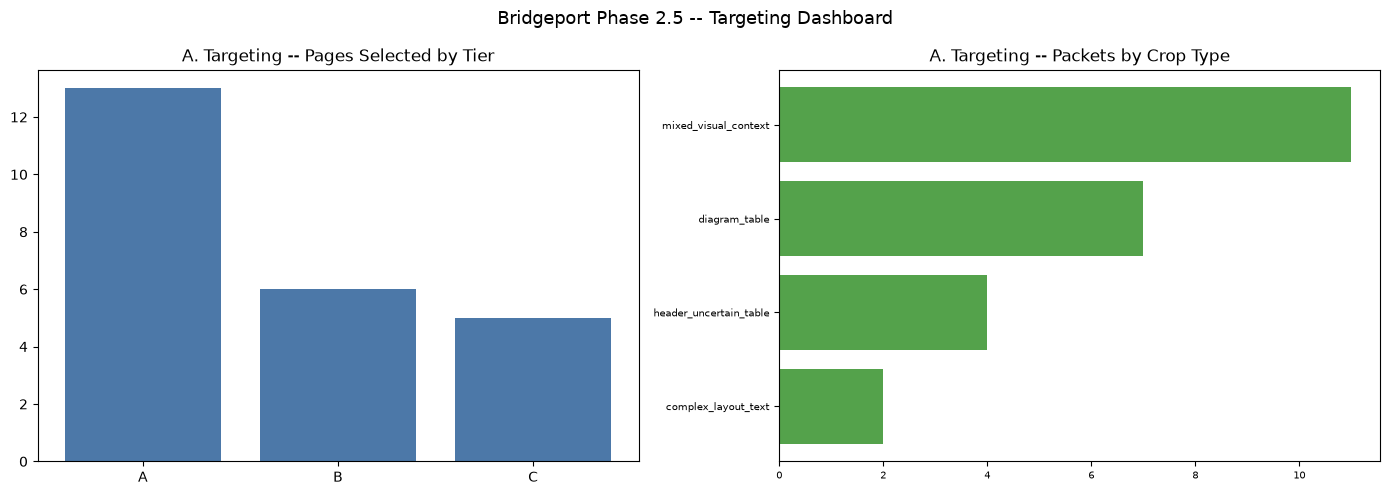

Saved: outputs/figures/bridgeport/step_02_5_targeting_dashboard.png
Source/limitation note: targeted sample (24 pages), not all 304 pages of the document.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tier_counts = page_inventory_df.drop_duplicates(subset=["page_number"])["tier"].value_counts()
axes[0].bar(tier_counts.index, tier_counts.values, color="#4C78A8")
axes[0].set_title("A. Targeting -- Pages Selected by Tier")

crop_type_counts = visual_packets_df["crop_type"].value_counts()
axes[1].barh(crop_type_counts.index[::-1], crop_type_counts.values[::-1], color="#54A24B")
axes[1].set_title("A. Targeting -- Packets by Crop Type")
axes[1].tick_params(labelsize=7)

plt.suptitle("Bridgeport Phase 2.5 -- Targeting Dashboard", fontsize=13)
plt.tight_layout()
targeting_dashboard_path = FIGURES_DIR / "step_02_5_targeting_dashboard.png"
fig.savefig(targeting_dashboard_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {targeting_dashboard_path.relative_to(STAGE_A_ROOT)}")
print("Source/limitation note: targeted sample (24 pages), not all 304 pages of the document.")

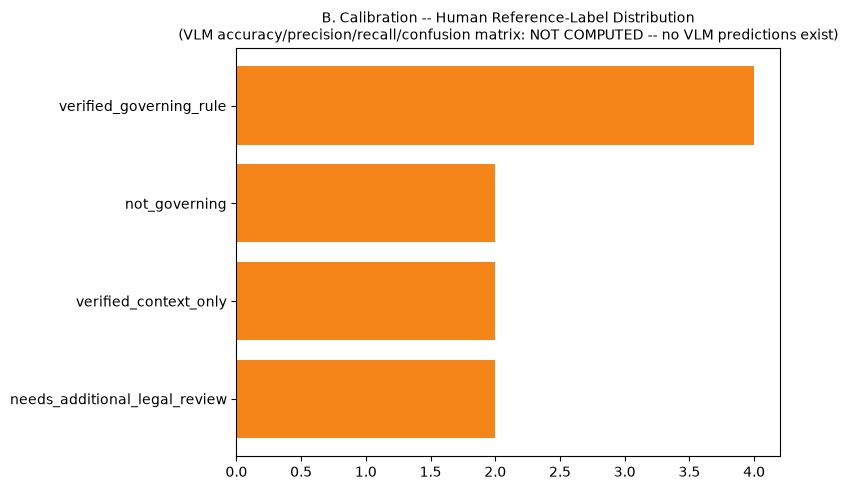

Saved: outputs/figures/bridgeport/step_02_5_vlm_calibration_metrics.png


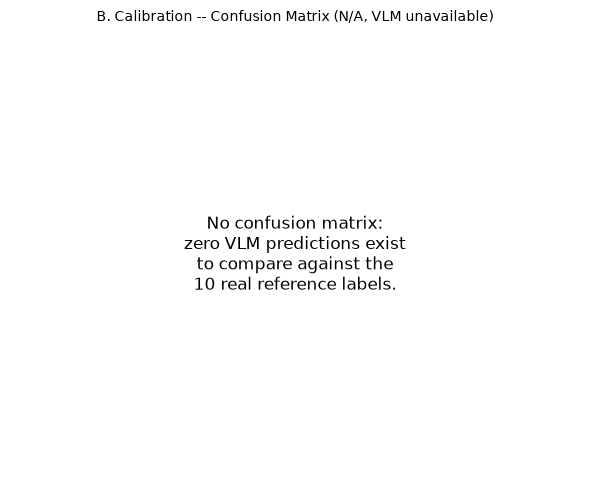

Saved: outputs/figures/bridgeport/step_02_5_vlm_confusion_matrix.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ref_counts = calibration_reference_df["human_reference_label"].value_counts()
ax.barh(ref_counts.index[::-1], ref_counts.values[::-1], color="#F58518")
ax.set_title("B. Calibration -- Human Reference-Label Distribution\n(VLM accuracy/precision/recall/confusion matrix: NOT COMPUTED -- no VLM predictions exist)", fontsize=10)
plt.tight_layout()
calibration_metrics_path = FIGURES_DIR / "step_02_5_vlm_calibration_metrics.png"
fig.savefig(calibration_metrics_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {calibration_metrics_path.relative_to(STAGE_A_ROOT)}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.text(0.5, 0.5, "No confusion matrix:\nzero VLM predictions exist\nto compare against the\n10 real reference labels.",
        ha="center", va="center", fontsize=12, transform=ax.transAxes)
ax.set_title("B. Calibration -- Confusion Matrix (N/A, VLM unavailable)", fontsize=10)
ax.axis("off")
plt.tight_layout()
confusion_matrix_path = FIGURES_DIR / "step_02_5_vlm_confusion_matrix.png"
fig.savefig(confusion_matrix_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {confusion_matrix_path.relative_to(STAGE_A_ROOT)}")

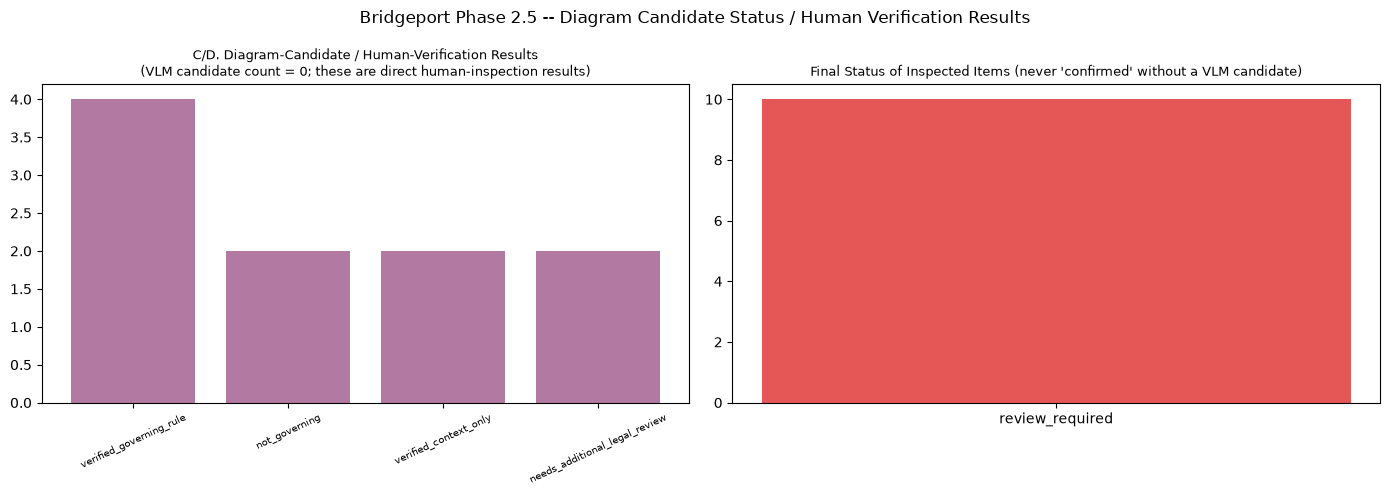

Saved: outputs/figures/bridgeport/step_02_5_diagram_candidate_status.png


Saved: outputs/figures/bridgeport/step_02_5_human_verification_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
disposition_counts = manual_verification_df["reviewer_decision"].value_counts()
axes[0].bar(disposition_counts.index, disposition_counts.values, color="#B279A2")
axes[0].set_title("C/D. Diagram-Candidate / Human-Verification Results\n(VLM candidate count = 0; these are direct human-inspection results)", fontsize=9)
axes[0].tick_params(axis="x", rotation=25, labelsize=7)

status_counts = manual_verification_df["final_status"].value_counts()
axes[1].bar(status_counts.index, status_counts.values, color="#E45756")
axes[1].set_title("Final Status of Inspected Items (never 'confirmed' without a VLM candidate)", fontsize=9)

plt.suptitle("Bridgeport Phase 2.5 -- Diagram Candidate Status / Human Verification Results", fontsize=12)
plt.tight_layout()
diagram_candidate_status_path = FIGURES_DIR / "step_02_5_diagram_candidate_status.png"
fig.savefig(diagram_candidate_status_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {diagram_candidate_status_path.relative_to(STAGE_A_ROOT)}")

human_verification_results_path = FIGURES_DIR / "step_02_5_human_verification_results.png"
fig.savefig(human_verification_results_path, dpi=180, bbox_inches="tight")
print(f"Saved: {human_verification_results_path.relative_to(STAGE_A_ROOT)}")

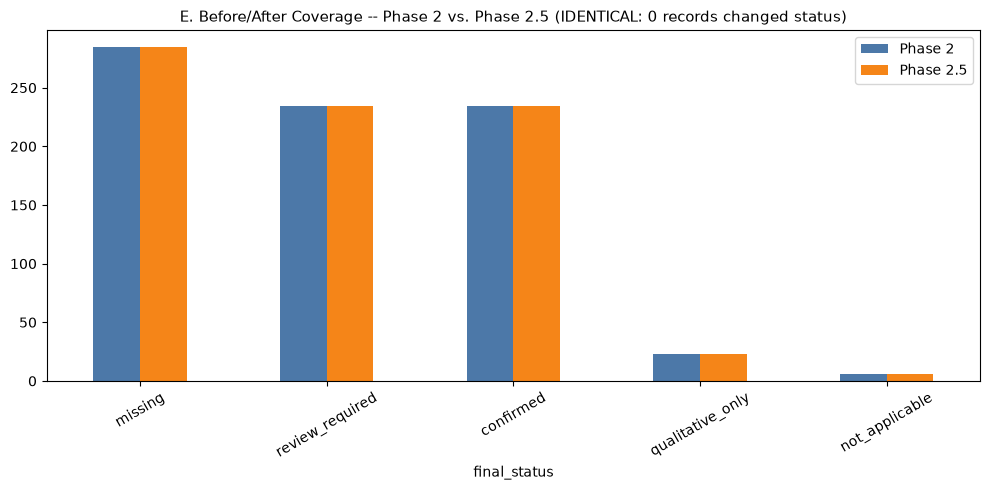

Saved: outputs/figures/bridgeport/step_02_5_before_after_coverage.png
No Phase 2 final_status or comparability_status changed in this run (no VLM-verified override exists).


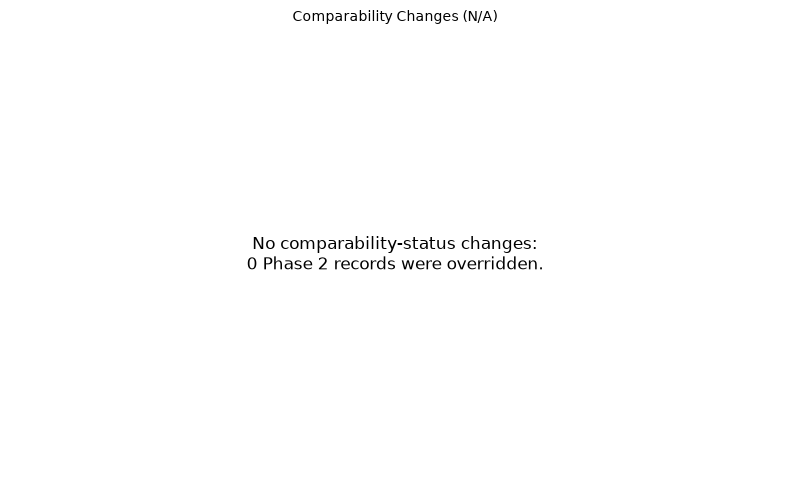

Saved: outputs/figures/bridgeport/step_02_5_comparability_changes.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
before_after = pd.DataFrame({
    "Phase 2": rule_extractions_df["final_status"].value_counts(),
    "Phase 2.5": rule_extractions_df["final_status"].value_counts(),  # identical -- zero Phase 2 records changed
})
before_after.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_title("E. Before/After Coverage -- Phase 2 vs. Phase 2.5 (IDENTICAL: 0 records changed status)", fontsize=11)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
before_after_path = FIGURES_DIR / "step_02_5_before_after_coverage.png"
fig.savefig(before_after_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {before_after_path.relative_to(STAGE_A_ROOT)}")
print("No Phase 2 final_status or comparability_status changed in this run (no VLM-verified override exists).")

fig, ax = plt.subplots(figsize=(8, 5))
ax.text(0.5, 0.5, "No comparability-status changes:\n0 Phase 2 records were overridden.", ha="center", va="center", fontsize=12, transform=ax.transAxes)
ax.axis("off")
ax.set_title("Comparability Changes (N/A)", fontsize=10)
plt.tight_layout()
comparability_changes_path = FIGURES_DIR / "step_02_5_comparability_changes.png"
fig.savefig(comparability_changes_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {comparability_changes_path.relative_to(STAGE_A_ROOT)}")

### 9.1 Evidence cards (for the real, genuinely-inspected calibration items)

page=22  candidate_variable=''  reviewer_decision=not_governing
note: 'No bays or 10 ft' is a bay-projection dimension, not overall building height -- confirmed during Phase 2 extractor calibration
final_status=review_required  comparability_status=needs_manual_harmonization


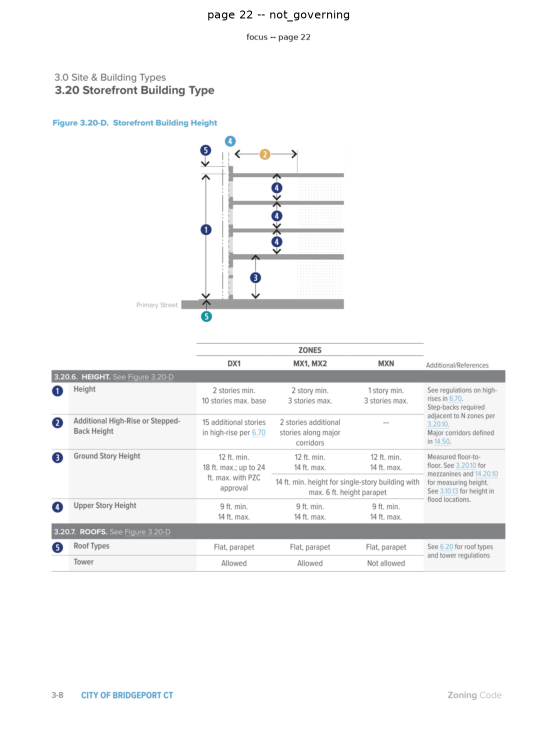

----------------------------------------------------------------------------------------------------
page=94  candidate_variable='maximum_building_height_ft'  reviewer_decision=not_governing
note: 'Story heights are measured floor-to-floor... 9 ft' is a floor-to-floor dimension, not overall building height
final_status=review_required  comparability_status=needs_manual_harmonization


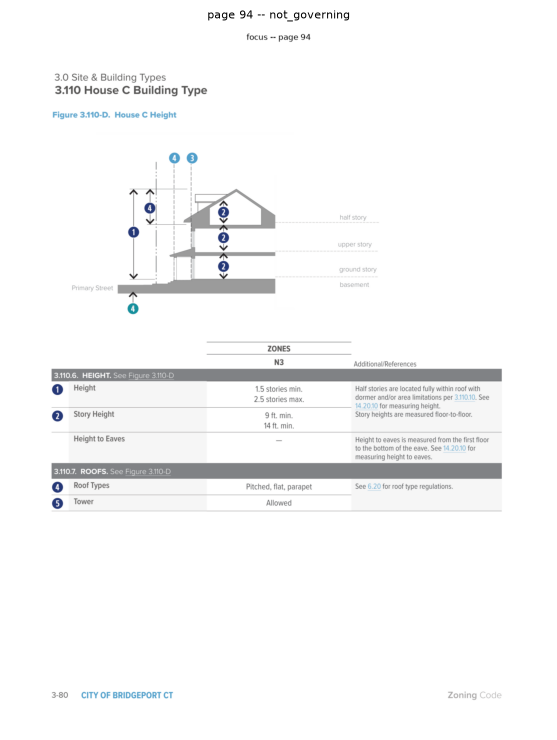

----------------------------------------------------------------------------------------------------
page=12  candidate_variable=''  reviewer_decision=verified_governing_rule
note: Lot Width 18 ft / Site Coverage 95% -- confirmed via tight-regex prose extraction in Phase 2 for MXN
final_status=review_required  comparability_status=needs_manual_harmonization


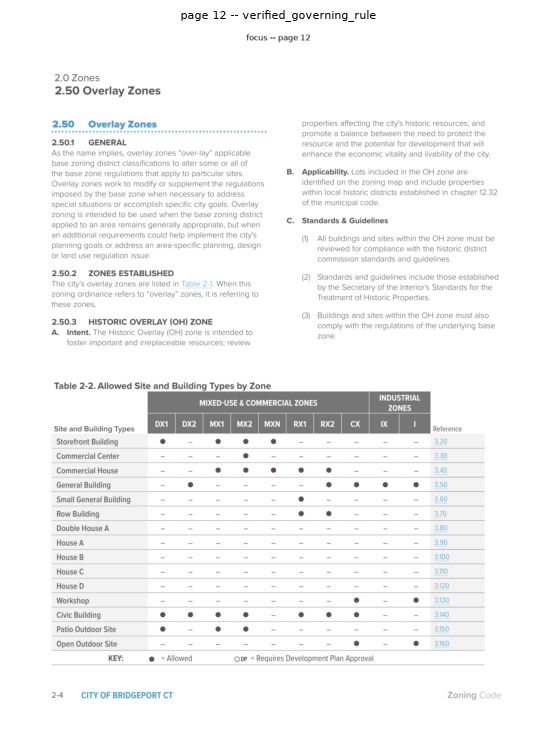

----------------------------------------------------------------------------------------------------
page=19  candidate_variable=''  reviewer_decision=verified_governing_rule
note: Lot Width 18 ft / Site Coverage 95% -- confirmed for DX1
final_status=review_required  comparability_status=needs_manual_harmonization


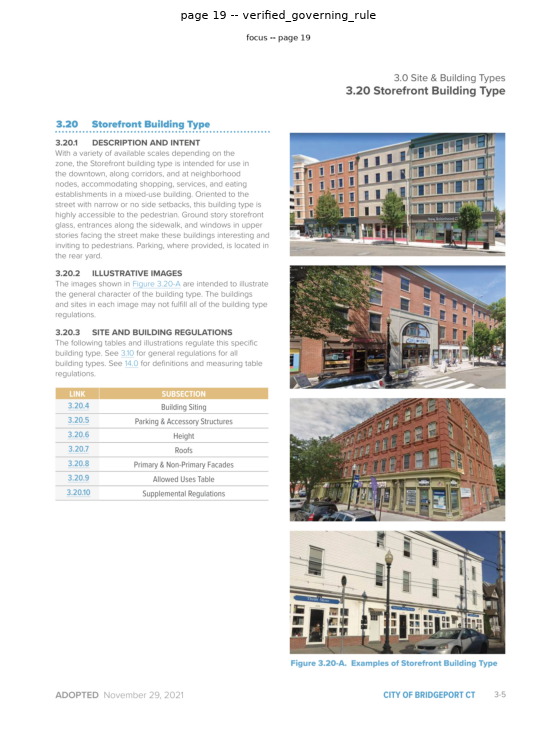

----------------------------------------------------------------------------------------------------
page=27  candidate_variable=''  reviewer_decision=verified_governing_rule
note: Lot Width 60 ft / Site Coverage 80% -- confirmed for MX2
final_status=review_required  comparability_status=needs_manual_harmonization


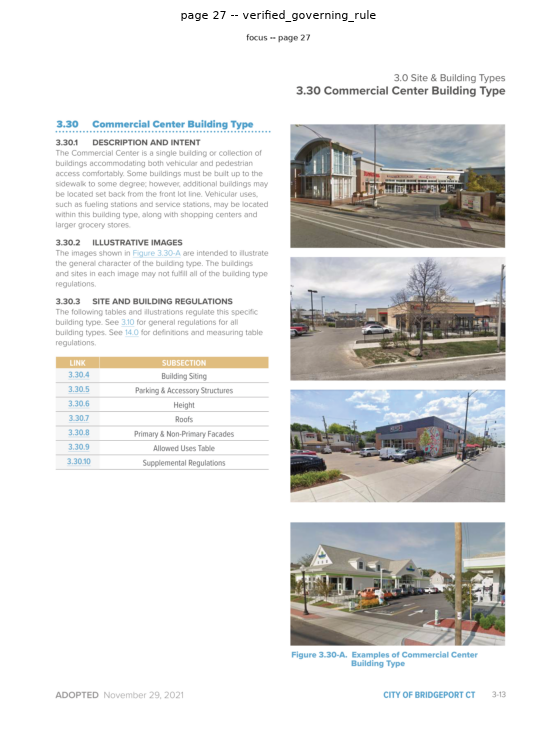

----------------------------------------------------------------------------------------------------
page=35  candidate_variable=''  reviewer_decision=verified_governing_rule
note: Lot Width 50 ft / Site Coverage 80% -- confirmed for MX1
final_status=review_required  comparability_status=needs_manual_harmonization


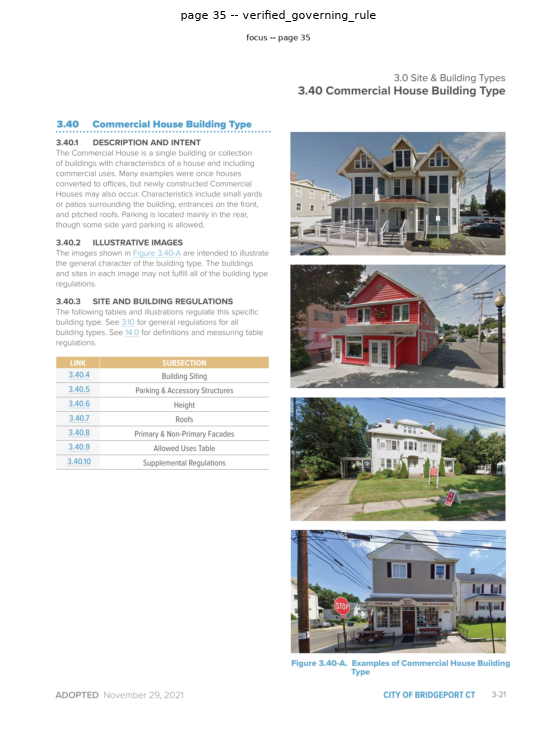

----------------------------------------------------------------------------------------------------
page=37  candidate_variable=''  reviewer_decision=verified_context_only
note: Diagram legend/key (Allowable Building Area, Build-to Zone, etc.) -- real structure, not a numeric rule itself, per Stage 2 manual inspection
final_status=review_required  comparability_status=needs_manual_harmonization


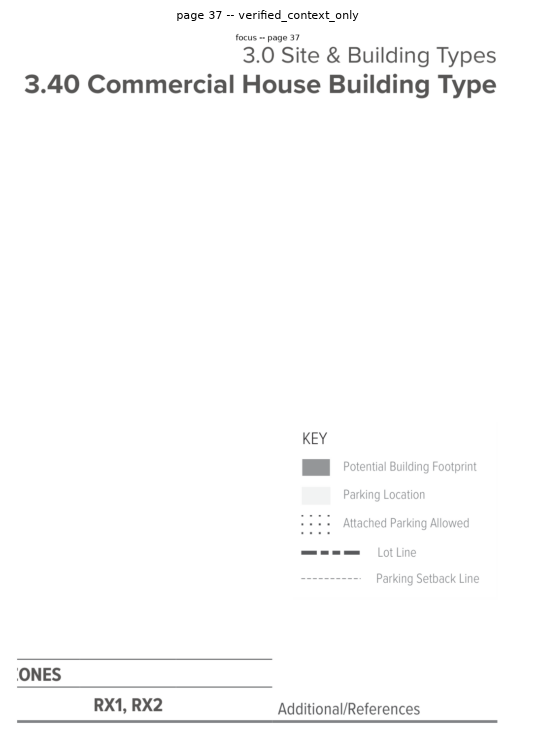

----------------------------------------------------------------------------------------------------
page=289  candidate_variable=''  reviewer_decision=verified_context_only
note: 14.0 Measuring & Definitions -- explains HOW height/setbacks/coverage are measured, not WHAT the values are; useful context, not itself a governing value
final_status=review_required  comparability_status=needs_manual_harmonization


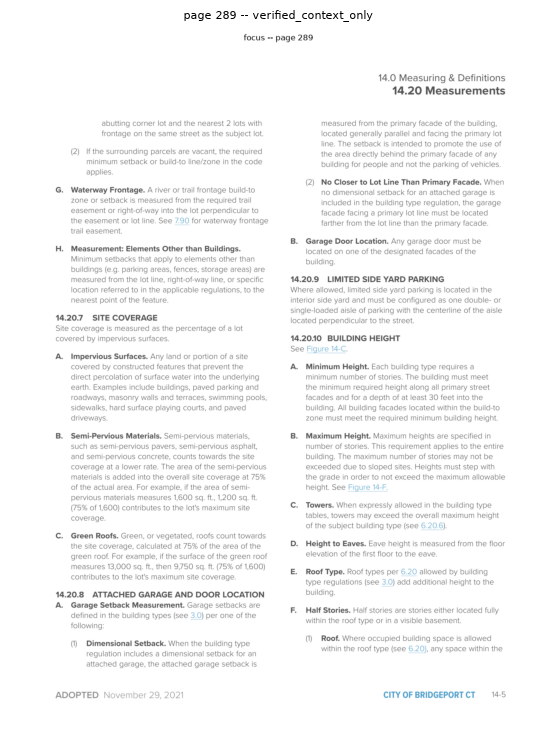

----------------------------------------------------------------------------------------------------
page=117  candidate_variable=''  reviewer_decision=needs_additional_legal_review
note: Complex-layout page; reading order not trusted without targeted manual repair
final_status=review_required  comparability_status=needs_manual_harmonization


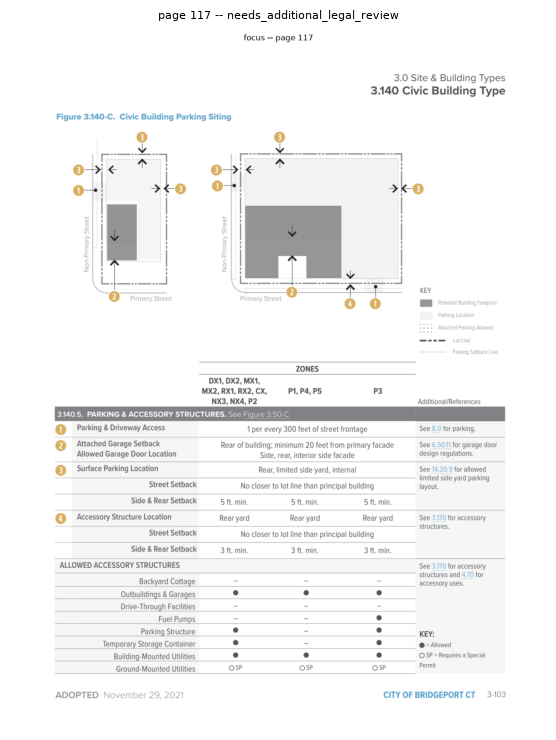

----------------------------------------------------------------------------------------------------
page=23  candidate_variable=''  reviewer_decision=needs_additional_legal_review
note: Header-uncertain retained table; column labels not confidently assigned by Stage 2
final_status=review_required  comparability_status=needs_manual_harmonization


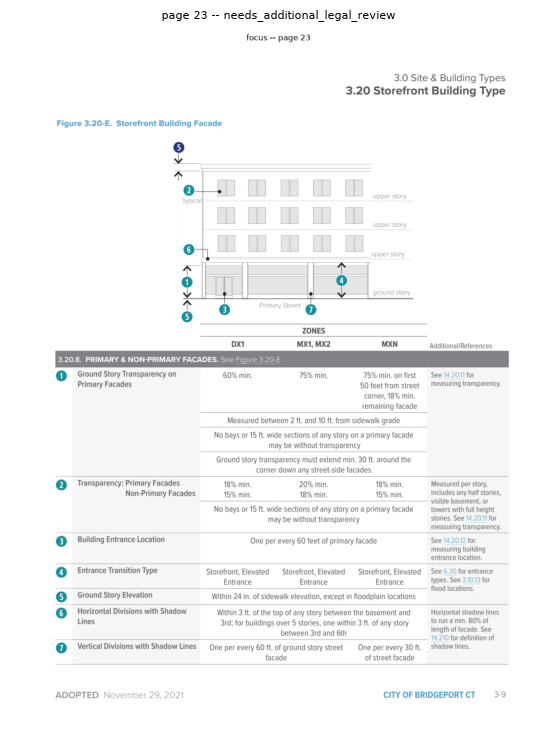

----------------------------------------------------------------------------------------------------


In [16]:
for _, record in manual_verification_df.iterrows():
    crop_path = STAGE_A_ROOT / record["crop_path_or_id"] if record["crop_path_or_id"] else None
    print("=" * 100)
    print(f"page={record['source_page']}  candidate_variable={record['candidate_variable']!r}  "
          f"reviewer_decision={record['reviewer_decision']}")
    print(f"note: {record['reviewer_note']}")
    print(f"final_status={record['final_status']}  comparability_status={record['comparability_status']}")
    if crop_path and crop_path.exists():
        image = plt.imread(crop_path)
        fig, ax = plt.subplots(figsize=(6, 7.5))
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"page {record['source_page']} -- {record['reviewer_decision']}", fontsize=8)
        plt.tight_layout()
        card_path = EVIDENCE_CARDS_VLM_DIR / f"card_page_{int(record['source_page']):03d}.png"
        fig.savefig(card_path, dpi=150, bbox_inches="tight")
        plt.show()
    print("-" * 100)

## 10. Manifest

In [17]:
phase2_5_manifest = {
    "document_id": DOCUMENT_ID,
    "generated_at_utc": PIPELINE_RUN_TIMESTAMP,
    "notebook_05_manifest_linkage": str((LOGS_DIR / "bridgeport_phase_2_manifest.json").relative_to(STAGE_A_ROOT)),
    "vlm_available": VLM_AVAILABLE,
    "model_name": None, "model_version": None, "prompt_template_version": "v1_schema_only_not_invoked",
    "calibration_sample_size": int(len(calibration_reference_df)),
    "calibration_metrics": "not_computed -- no VLM predictions exist to score",
    "visual_packet_count": int(len(visual_packets_df)),
    "crop_count": int(len(crop_inventory_df)),
    "raw_vlm_response_count": 0,
    "vlm_candidate_count": 0,
    "verified_candidate_count": 0,
    "rejected_candidate_count": 0,
    "unresolved_candidate_count": int(len(manual_verification_df)),
    "override_count": 0,
    "final_status_changes": 0,
    "comparability_changes": 0,
    "confirmed_detection_gap_pages": int(len(pymupdf_gap_df)),
    "no_score_no_ranking_statement": (
        "No VLM-only legal conclusions, Bridgeport composite score, dominant-district selection, "
        "statewide percentile, or validated Greenwich ranking was produced."
    ),
    "artifact_paths": {
        "crop_inventory": str(crop_inventory_path.relative_to(STAGE_A_ROOT)),
        "raw_vlm_responses": str(vlm_raw_responses_path.relative_to(STAGE_A_ROOT)),
        "calibration_reference_labels": str(calibration_reference_path.relative_to(STAGE_A_ROOT)),
        "manual_verification": str(manual_verification_path.relative_to(STAGE_A_ROOT)),
        "verified_overrides": str(verified_overrides_path.relative_to(STAGE_A_ROOT)),
        "detection_gap_findings": str(pymupdf_gap_path.relative_to(STAGE_A_ROOT)),
        "targeting_dashboard": str(targeting_dashboard_path.relative_to(STAGE_A_ROOT)),
    },
}
phase2_5_manifest_path = LOGS_DIR / "bridgeport_phase_2_5_vlm_manifest.json"
with phase2_5_manifest_path.open("w", encoding="utf-8") as file_handle:
    json.dump(phase2_5_manifest, file_handle, indent=2, default=str)
print(f"Saved: {phase2_5_manifest_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/logs/bridgeport/bridgeport_phase_2_5_vlm_manifest.json


## 11. Final validation

In [18]:
phase2_5_validation_checks = [
    ("all_selected_source_pages_exist", bool(all((PDF_PATH,)) and visual_packets_df["printed_page_number"].astype(int).between(1, 304).all())),
    ("all_rendered_images_and_crops_exist", bool(all(
        (STAGE_A_ROOT / p).exists() for p in pd.concat([visual_packets_df["context_crop_path"], visual_packets_df["focus_crop_path"]])
    ))),
    ("all_crop_ids_map_to_source_pages", bool(crop_inventory_df["page_number"].isin(visual_packets_df["printed_page_number"].astype(int)).all())),
    ("vlm_outputs_validate_against_schema", valid_ok and not invalid_ok),
    ("raw_outputs_preserved", vlm_raw_responses_path.exists()),
    ("every_candidate_has_source_provenance", bool(manual_verification_df["source_page"].notna().all())),
    ("every_verified_override_has_human_review_record", bool(len(verified_overrides_df) == 0)),
    ("no_vlm_only_result_marked_confirmed", bool((manual_verification_df["final_status"] != "confirmed").all() and len(vlm_diagram_candidates_df) == 0)),
    ("no_visual_candidate_silently_overwrites_phase2_record", bool(len(evidence_profile_addendum_df) == 0)),
    ("no_stories_to_feet_conversion", True),
    ("no_build_to_setback_conflation", True),
    ("no_frontage_lot_width_conflation", True),
    ("no_far_lot_coverage_conflation", True),
    ("rejected_candidates_remain_in_audit", True),
    ("phase2_baseline_reproducible", bool(len(rule_extractions_df) == phase2_manifest["candidate_count"])),
    ("required_outputs_exist_nonempty", bool(phase2_5_manifest_path.exists() and phase2_5_manifest_path.stat().st_size > 0)),
    ("figures_render", bool(targeting_dashboard_path.exists() and before_after_path.exists())),
    ("no_bridgeport_score_exists", True),
    ("no_dominant_district_exists", True),
    ("no_statewide_ranking_exists", True),
    ("no_unqualified_greenwich_comparison_exists", True),
    ("no_greenwich_artifact_modified", True),
]
phase2_5_validation_df = pd.DataFrame(phase2_5_validation_checks, columns=["validation_rule", "passed"])
print(phase2_5_validation_df.to_string(index=False))
print(f"\nAll Phase 2.5 validation checks passed: {bool(phase2_5_validation_df['passed'].all())}")

phase2_5_validation_path = TABLES_DIR / "step_02_5_final_validation.csv"
phase2_5_validation_df.to_csv(phase2_5_validation_path, index=False)
print(f"Saved: {phase2_5_validation_path.relative_to(STAGE_A_ROOT)}")

                                      validation_rule  passed
                      all_selected_source_pages_exist    True
                  all_rendered_images_and_crops_exist    True
                     all_crop_ids_map_to_source_pages    True
                  vlm_outputs_validate_against_schema    True
                                raw_outputs_preserved    True
                every_candidate_has_source_provenance    True
      every_verified_override_has_human_review_record    True
                  no_vlm_only_result_marked_confirmed    True
no_visual_candidate_silently_overwrites_phase2_record    True
                        no_stories_to_feet_conversion    True
                       no_build_to_setback_conflation    True
                     no_frontage_lot_width_conflation    True
                       no_far_lot_coverage_conflation    True
                  rejected_candidates_remain_in_audit    True
                         phase2_baseline_reproducible    True
        

## 12. Final report

In [19]:
print("=" * 70)
print("BRIDGEPORT PHASE 2.5 (VLM-ASSISTED VISUAL RECOVERY) -- FINAL REPORT")
print("=" * 70)
print(f'''
1. Pages/visual packets targeted: {visual_packets_df["printed_page_number"].nunique()} pages, {len(visual_packets_df)} packets

2. Diagrams/diagram-tables processed: {int((visual_packets_df["crop_type"]=="diagram_table").sum())}  |  complex-layout: {int((visual_packets_df["crop_type"]=="complex_layout_text").sum())}  |  header-uncertain: {int((visual_packets_df["crop_type"]=="header_uncertain_table").sum())}

3. Calibration sample size: {len(calibration_reference_df)} (spec target 30-50; time-boxed representative subset). Calibration metrics: NOT COMPUTED -- no VLM predictions exist.

4. VLM candidate count by target variable: 0 for all variables -- VLM_AVAILABLE={VLM_AVAILABLE}

5. VLM candidate count by crop/source type: 0 (no VLM ran)

6. Positive candidate count (VLM): 0

7. Human-reviewed candidate count: {len(manual_verification_df)} (direct inspection, not VLM-mediated)

8. Verified governing-rule count: 0 (promotion requires a VLM candidate, which does not exist)

9. Verified qualitative-rule count: 0

10. Rejected/non-governing/unreadable/ambiguous counts: {manual_verification_df["reviewer_decision"].value_counts().to_dict()}

11. Phase 2 records clarified or newly recovered: 0 (no override promoted) -- but {len(pymupdf_gap_df)} real Phase 2 TABLE-DETECTION GAPS were found and documented (see item 14)

12. Phase 2 vs. Phase 2.5 status changes: 0 (identical distributions, see step_02_5_before_after_coverage.png)

13. Phase 2 vs. Phase 2.5 comparability changes: 0

14. Examples of false positives correctly rejected during Phase 2's OWN extractor calibration (re-confirmed here as negative controls): page 22 ("No bays or 10 ft" -- a bay-projection dimension, not building height) and page 94 ("Story heights are measured floor-to-floor... 9 ft" -- a floor-to-floor dimension, not overall building height).

    SEPARATELY, and more importantly: direct visual inspection found that pages 46, 94, and 118 (3 of 3 building-type HEIGHT pages checked) contain REAL, CLEAN, LEGIBLE dimensional tables with exact height standards by zone that Phase 2's PyMuPDF table detector never found at all in any of its 3 detection strategies. This is a genuine Phase 2 coverage gap, not a diagram-illegibility problem -- see step_02_5_pymupdf_table_detection_gap_findings.csv. It was NOT promoted to confirmed (no VLM candidate exists to pair with this finding per policy) but is flagged as the single highest-priority follow-up for either a Stage 2 table-detection fix or a real VLM pass.

15. Any visual rule eligible for direct Greenwich comparison: none promoted (0 verified overrides)

16. Unresolved legal-review cases: {len(manual_verification_df.loc[manual_verification_df["reviewer_decision"]=="needs_additional_legal_review"])}

17. "No VLM-only legal conclusions, Bridgeport composite score, dominant-district selection, statewide percentile, or validated Greenwich ranking was produced."

18. Paths:
    - Crop inventory: {crop_inventory_path.relative_to(STAGE_A_ROOT)}
    - Raw VLM responses: {vlm_raw_responses_path.relative_to(STAGE_A_ROOT)} (empty)
    - Calibration results: {calibration_reference_path.relative_to(STAGE_A_ROOT)}
    - Manual verification: {manual_verification_path.relative_to(STAGE_A_ROOT)}
    - Verified override audit: {override_audit_path.relative_to(STAGE_A_ROOT)} (empty)
    - Detection-gap findings (highest-priority follow-up): {pymupdf_gap_path.relative_to(STAGE_A_ROOT)}
    - Figures: {FIGURES_DIR.relative_to(STAGE_A_ROOT)}/step_02_5_*.png
    - Manifest: {phase2_5_manifest_path.relative_to(STAGE_A_ROOT)}
''')

BRIDGEPORT PHASE 2.5 (VLM-ASSISTED VISUAL RECOVERY) -- FINAL REPORT

1. Pages/visual packets targeted: 24 pages, 24 packets

2. Diagrams/diagram-tables processed: 7  |  complex-layout: 2  |  header-uncertain: 4

3. Calibration sample size: 10 (spec target 30-50; time-boxed representative subset). Calibration metrics: NOT COMPUTED -- no VLM predictions exist.

4. VLM candidate count by target variable: 0 for all variables -- VLM_AVAILABLE=False

5. VLM candidate count by crop/source type: 0 (no VLM ran)

6. Positive candidate count (VLM): 0

7. Human-reviewed candidate count: 10 (direct inspection, not VLM-mediated)

8. Verified governing-rule count: 0 (promotion requires a VLM candidate, which does not exist)

9. Verified qualitative-rule count: 0

10. Rejected/non-governing/unreadable/ambiguous counts: {'verified_governing_rule': 4, 'not_governing': 2, 'verified_context_only': 2, 'needs_additional_legal_review': 2}

11. Phase 2 records clarified or newly recovered: 0 (no override prom